<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/09_1_Reto_PCA_PMU_JOHAN_ORDO%C3%91EZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ESTUDIANTE:** JOHAN DAVID ORDOÑEZ CASTRO - **CODIGO:** 224393001

# Taller: PCA - Principal Component Analysis

**Maestría en Ingeniería Electrónica (MaIE)**  
Universidad de Nariño  
Curso: Introducción a la Ciencia de Datos  
Instructor: Carlos Andrés Viteri Mera

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# DESARROLLO RETO

## Dataset: PMU Dataset for Power Line Fault Detection

### Descripción del Dataset

Las **Unidades de Medición Fasorial (PMU)** son dispositivos de alta precisión instalados en la red eléctrica que miden magnitudes de voltaje y corriente en tiempo real. Este dataset contiene mediciones de corriente y voltaje para las tres fases del sistema, con etiquetas que indican el tipo de falla presente:

| Etiqueta | Descripción |
|----------|-------------|
| `Normal` | Operación normal, sin falla |
| `LG`     | Falla fase-tierra (*Line-to-Ground*) |
| `LL`     | Falla fase-fase (*Line-to-Line*) |
| `3P`     | Falla trifásica (*Three-Phase*) |

**Variables (features) del dataset:**
- `Ia`, `Ib`, `Ic` — Corrientes de fase A, B, C
- `Va`, `Vb`, `Vc` — Voltajes de fase A, B, C
- `G`, `C`, `B`, `A` — Columnas one-hot que codifican el tipo de falla (usadas para construir la etiqueta)

---
## Paso 0: Descarga del Dataset desde Kaggle

Por medio de un token generado en la pagina de Kaggle se puede descarga el Dataset.

In [ ]:
# Instalar kagglehub
!pip install kagglehub -q

In [ ]:
import os

#Token de kagge
token = "KGAT_28938b667c0bb0e20597ebd79c85196b"  # <-- Reemplaza con tu token actual

# Configurar el token para kagglehub
os.environ["KAGGLE_API_TOKEN"] = token
print("Token configurado correctamente")

Token configurado correctamente


In [ ]:
import kagglehub

# Descargar el dataset
ruta = kagglehub.dataset_download(
    'esathyaprakash/electrical-fault-detection-and-classification'
)
print(f"Dataset descargado en: {ruta}")

# Listar archivos disponibles
import os
archivos = os.listdir(ruta)
print("Archivos disponibles:", archivos)

Dataset descargado en: /root/.cache/kagglehub/datasets/esathyaprakash/electrical-fault-detection-and-classification/versions/2
Archivos disponibles: ['detect_dataset.csv', 'classData.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import plotly.express as px

# Cargar el archivo classData.csv (contiene la clasificación por tipo de falla)
ruta_csv = os.path.join(ruta, 'classData.csv')
df = pd.read_csv(ruta_csv)

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nColumnas disponibles: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (7861, 10)

Columnas disponibles: ['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

Primeras filas:


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [ ]:
# Reconstruir la etiqueta de falla desde las columnas one-hot G, C, B, A
# G = falla a tierra, C/B/A = fases involucradas
def obtener_etiqueta(row):
    if row['G'] == 0 and row['C'] == 0 and row['B'] == 0 and row['A'] == 0:
        return 'Normal'
    elif row['G'] == 1 and row['C'] == 0 and row['B'] == 0:
        return 'LG'
    elif row['G'] == 0 and (row['C'] == 1 or row['B'] == 1 or row['A'] == 1):
        return 'LL'
    elif row['G'] == 1 and row['C'] == 1 and row['B'] == 1 and row['A'] == 1:
        return '3P'
    else:
        return 'Otro'

df['fault_type'] = df.apply(obtener_etiqueta, axis=1)

print("Distribución de clases:")
print(df['fault_type'].value_counts())

Distribución de clases:
fault_type
Normal    2365
LL        2100
Otro      1134
3P        1133
LG        1129
Name: count, dtype: int64


---
## 1. Importar los datos y separar la variable dependiente

> **CORRECCIÓN APLICADA:** Se eliminó la definición duplicada de `features` que usaba nombres de columnas inexistentes (`Va_mag`, `Ia_mag`, `Freq`, `ROCOF`). Se usan las columnas reales del dataset: `Ia, Ib, Ic, Va, Vb, Vc`.

In [ ]:
# =====================================================================
# 1. Importar los datos y separar la variable independiente
# =====================================================================

# Columnas reales del dataset: corrientes y voltajes de las tres fases
features = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

# Separar las características (X) y la variable objetivo (y)
X = df[features]
# La variable independiente es el tipo de falla:
# Normal, LG (Line-to-Ground), LL (Line-to-Line), 3P (Three-Phase)
y = df['fault_type']

# Manejo de valores NaN antes de la estandarización
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=features)

# Los datos se deben estandarizar antes de calcular la covarianza y el PCA
# para que todas las variables contribuyan equitativamente (media 0 y varianza 1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Estadísticas ANTES de estandarizar:")
print(X.describe().round(4))
print("\nEstadísticas DESPUÉS de estandarizar:")
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.describe().round(4))

Estadísticas ANTES de estandarizar:
              Ia         Ib         Ic         Va         Vb         Vc
count  7861.0000  7861.0000  7861.0000  7861.0000  7861.0000  7861.0000
mean     13.7212   -44.8453    34.3924    -0.0077     0.0012     0.0065
std     464.7417   439.2692   371.1074     0.2892     0.3134     0.3079
min    -883.5423  -900.5270  -883.3578    -0.6207    -0.6080    -0.6127
25%    -119.8025  -271.8459   -61.0342    -0.1303    -0.1595    -0.2160
50%       2.0428     5.5133    -4.3267    -0.0053     0.0016     0.0093
75%     227.2464    91.1943    49.1151     0.1116     0.1535     0.2400
max     885.7386   889.8689   901.2743     0.5953     0.6279     0.6002

Estadísticas DESPUÉS de estandarizar:
              Ia         Ib         Ic         Va         Vb         Vc
count  7861.0000  7861.0000  7861.0000  7861.0000  7861.0000  7861.0000
mean      0.0000    -0.0000     0.0000     0.0000    -0.0000     0.0000
std       1.0001     1.0001     1.0001     1.0001     1.0001 

---
## 2. Calcular la Matriz de Covarianza y Mapa de Calor

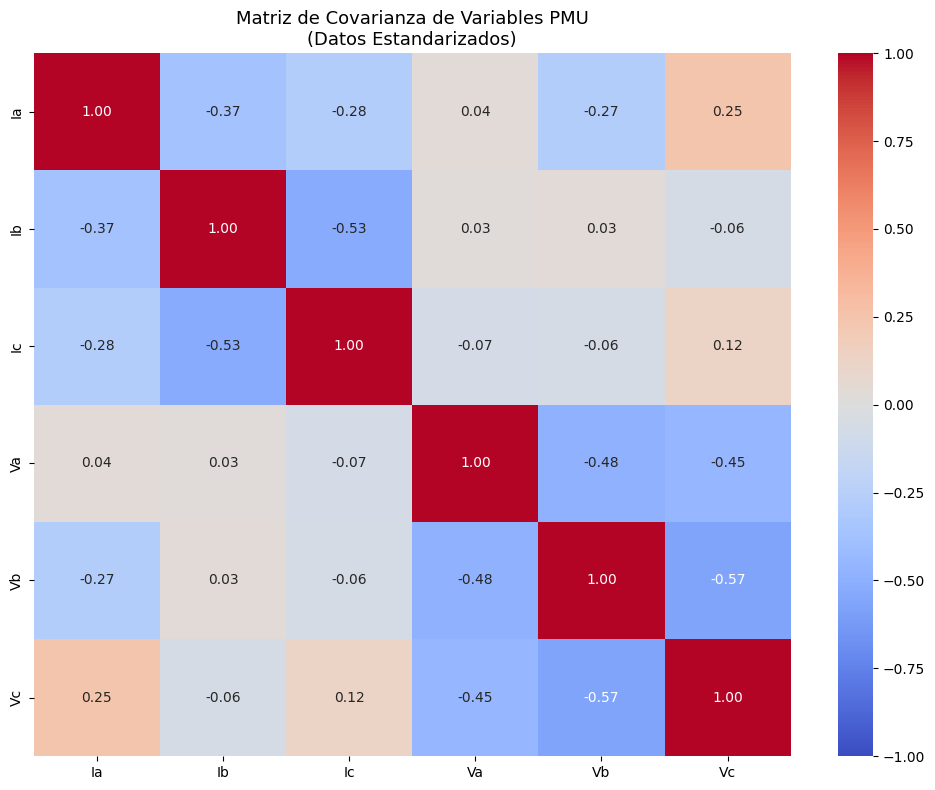

In [ ]:
# =====================================================================
# 2. Calcular la matriz de covarianza y graficar mapa de calor
# =====================================================================

# Calcular la matriz de covarianza sobre los datos estandarizados
# Sobre datos estandarizados, la covarianza equivale a la correlación
cov_matrix = np.cov(X_scaled, rowvar=False)

# Graficar la matriz de covarianza utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cov_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    xticklabels=features,
    yticklabels=features,
    vmin=-1, vmax=1
)
plt.title('Matriz de Covarianza de Variables PMU\n(Datos Estandarizados)', fontsize=13)
plt.tight_layout()
plt.show()


---
## 3. Realizar el Análisis de Componentes Principales (PCA)

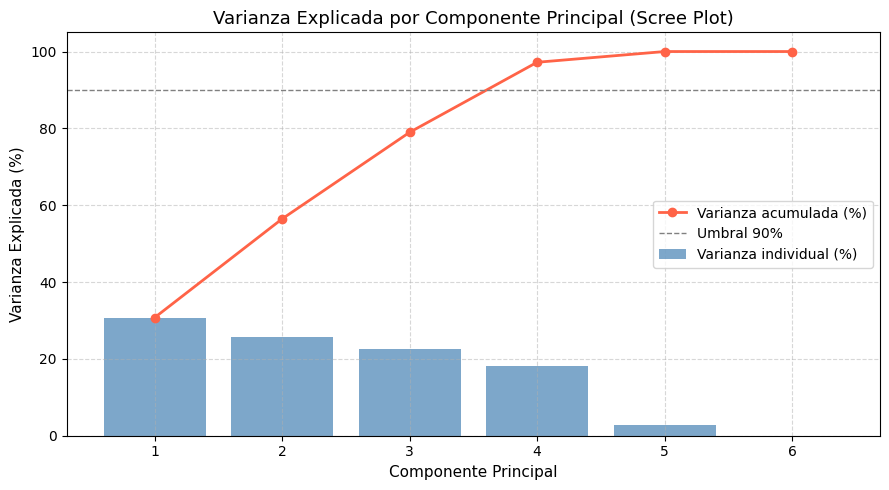

Varianza explicada por cada componente:
  CP1: 30.74%  (acumulada: 30.74%)
  CP2: 25.70%  (acumulada: 56.44%)
  CP3: 22.53%  (acumulada: 78.97%)
  CP4: 18.23%  (acumulada: 97.21%)
  CP5: 2.79%  (acumulada: 100.00%)
  CP6: 0.00%  (acumulada: 100.00%)


In [ ]:
# =====================================================================
# 3. Realizar el análisis de componentes principales (PCA)
# =====================================================================

# Inicializamos y ajustamos el modelo PCA a toda la matriz estandarizada
pca = PCA()
pca.fit(X_scaled)

# Varianza explicada acumulada para decidir cuántos componentes usar
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 5))

# Barras de varianza individual
plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_ * 100,
    color='steelblue',
    alpha=0.7,
    label='Varianza individual (%)'
)

# Línea de varianza acumulada
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker='o',
    color='tomato',
    linewidth=2,
    label='Varianza acumulada (%)'
)

plt.axhline(y=90, color='gray', linestyle='--', linewidth=1, label='Umbral 90%')
plt.xlabel('Componente Principal', fontsize=11)
plt.ylabel('Varianza Explicada (%)', fontsize=11)
plt.title('Varianza Explicada por Componente Principal (Scree Plot)', fontsize=13)
# CORRECCIÓN: se usa len(features) = 6, no 8
plt.xticks(range(1, len(features) + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Varianza explicada por cada componente:")
for i, (ind, acum) in enumerate(zip(pca.explained_variance_ratio_ * 100, varianza_acumulada), 1):
    print(f"  CP{i}: {ind:.2f}%  (acumulada: {acum:.2f}%)")

---
## 4. Obtener y Mostrar los Dos Componentes Principales (Mayor Varianza)

Varianza explicada por los primeros 4 componentes:
  CP1: 30.74%
  CP2: 25.70%
  CP3: 22.53%
  CP4: 18.23%

Varianza total explicada (CP1–CP4): 97.21%

Eigenvalues: [1.8447 1.5421 1.3521 1.0942 0.1676 0.    ]

Cargas (weights) del Componente Principal 1:
      Ia: +0.4413
      Ib: -0.3917
      Ic: +0.2177
      Va: +0.0030
      Vb: -0.5462
      Vc: +0.5532

Cargas (weights) del Componente Principal 2:
      Ia: +0.2114
      Ib: +0.4009
      Ic: -0.5457
      Va: +0.5560
      Vb: -0.4235
      Vc: -0.0911

Cargas (weights) del Componente Principal 3:
      Ia: -0.0973
      Ib: -0.4217
      Ic: +0.4335
      Va: +0.6168
      Vb: -0.0920
      Vc: -0.4857

Cargas (weights) del Componente Principal 4:
      Ia: +0.6839
      Ib: -0.3938
      Ic: -0.3615
      Va: -0.0899
      Vb: +0.3819
      Vc: -0.3044


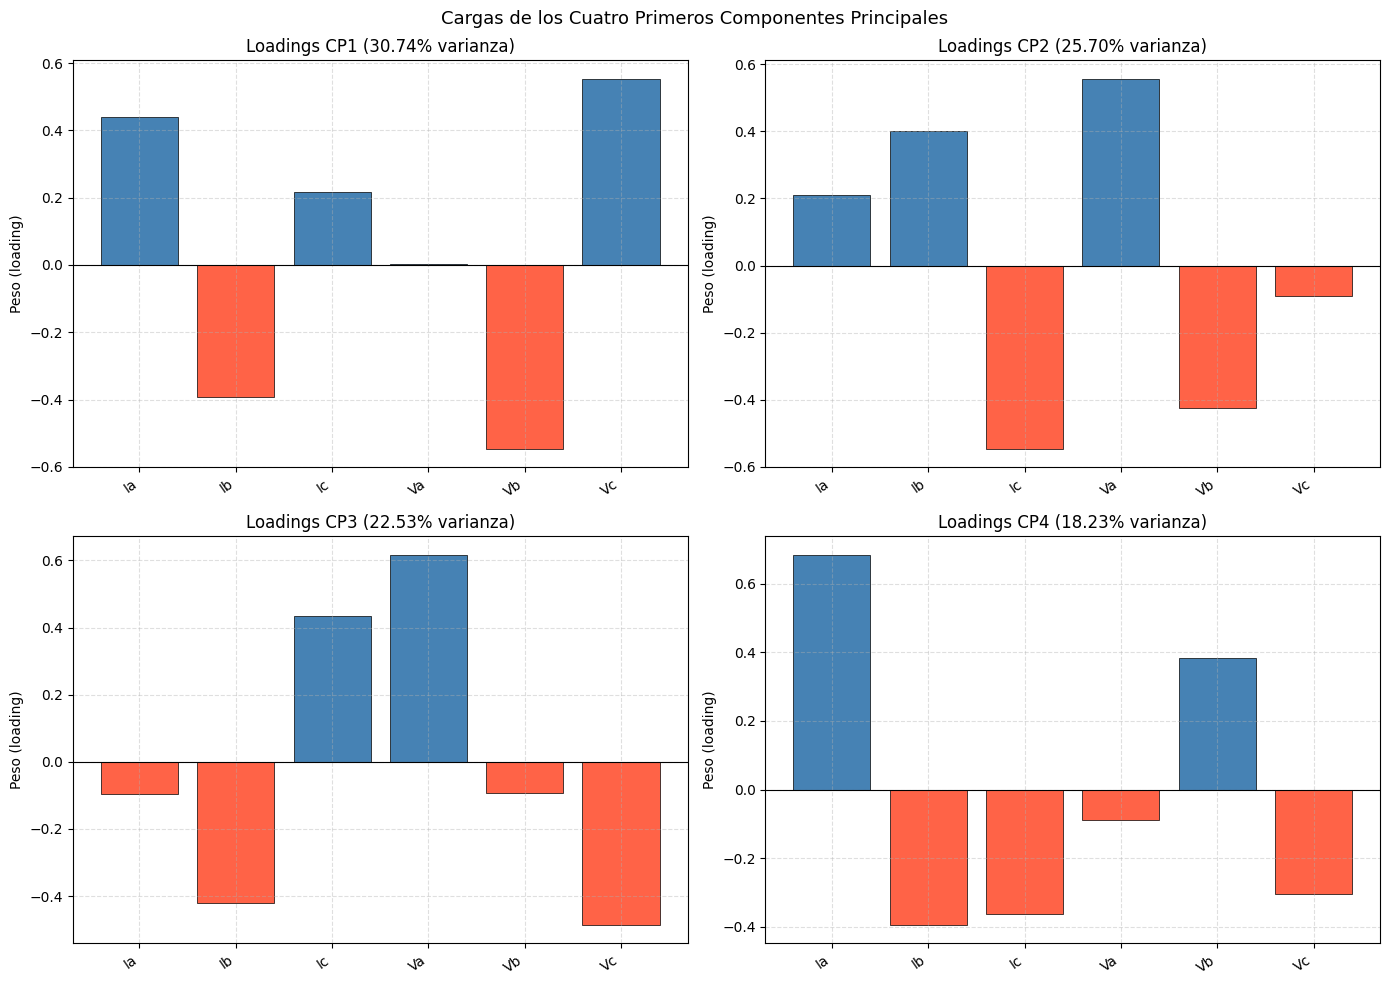

In [ ]:
# =====================================================================
# 4. Obtener y mostrar los cuatro componentes principales (mayor varianza)
# =====================================================================

# Seleccionamos los 4 primeros componentes
top_4_components = pca.components_[:4]
var_explicada = pca.explained_variance_ratio_ * 100
eigenvalues = pca.explained_variance_

print("Varianza explicada por los primeros 4 componentes:")
for i in range(4):
    print(f"  CP{i+1}: {var_explicada[i]:.2f}%")

print(f"\nVarianza total explicada (CP1–CP4): {sum(var_explicada[:4]):.2f}%")
print(f"\nEigenvalues: {eigenvalues.round(4)}")

# Mostrar las cargas (loadings) de cada componente
for idx in range(4):
    print(f"\nCargas (weights) del Componente Principal {idx+1}:")
    for feature, weight in zip(features, top_4_components[idx, :]):
        signo = '+' if weight >= 0 else '-'
        print(f"  {feature:>6}: {signo}{abs(weight):.4f}")

# Gráficos de barras de los loadings
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, ax in enumerate(axes.flat):
    colores = ['steelblue' if w >= 0 else 'tomato' for w in top_4_components[idx, :]]
    ax.bar(features, top_4_components[idx, :], color=colores, edgecolor='k', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Loadings CP{idx+1} ({var_explicada[idx]:.2f}% varianza)', fontsize=12)
    ax.set_ylabel('Peso (loading)')
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(features, rotation=35, ha='right')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Cargas de los Cuatro Primeros Componentes Principales', fontsize=13)
plt.tight_layout()
plt.show()


---
## 5. Calcular las Dos Nuevas Variables (Componentes) para Cada Fila

In [ ]:
# =====================================================================
# 5. Calcular las cuatro nuevas variables (Componentes) para cada fila
# =====================================================================

# Se aplica la transformación para proyectar los datos originales
# en el nuevo espacio definido por los cuatro primeros componentes
pca_4 = PCA(n_components=4)
X_pca = pca_4.fit_transform(X_scaled)

# Se crea un nuevo DataFrame con estos resultados
df_pca = pd.DataFrame(data=X_pca,
                      columns=['Componente Principal 1',
                               'Componente Principal 2',
                               'Componente Principal 3',
                               'Componente Principal 4'])

# Se añade de vuelta la variable de etiqueta 'fault_type'
df_pca['fault_type'] = y.values

print("Dimensiones del DataFrame transformado:", df_pca.shape)
print("\nPrimeras filas del espacio PCA:")
print(df_pca.head(8))



Dimensiones del DataFrame transformado: (7861, 5)

Primeras filas del espacio PCA:
   Componente Principal 1  Componente Principal 2  Componente Principal 3  \
0               -0.412940                0.929179                1.404285   
1               -0.444360                0.678380                1.113459   
2               -0.522219                0.544585                0.964424   
3               -0.575218                0.451598                0.873353   
4               -0.607829                0.366416                0.796999   
5               -0.614534                0.302938                0.753485   
6               -0.626516                0.331252                0.824381   
7               -0.687716                0.495918                1.055702   

   Componente Principal 4 fault_type  
0               -0.343613         LG  
1               -0.529378         LG  
2               -0.601080         LG  
3               -0.653455         LG  
4               -0.710520   

---
## 6. Scatterplot 2D Coloreado por Tipo de Falla

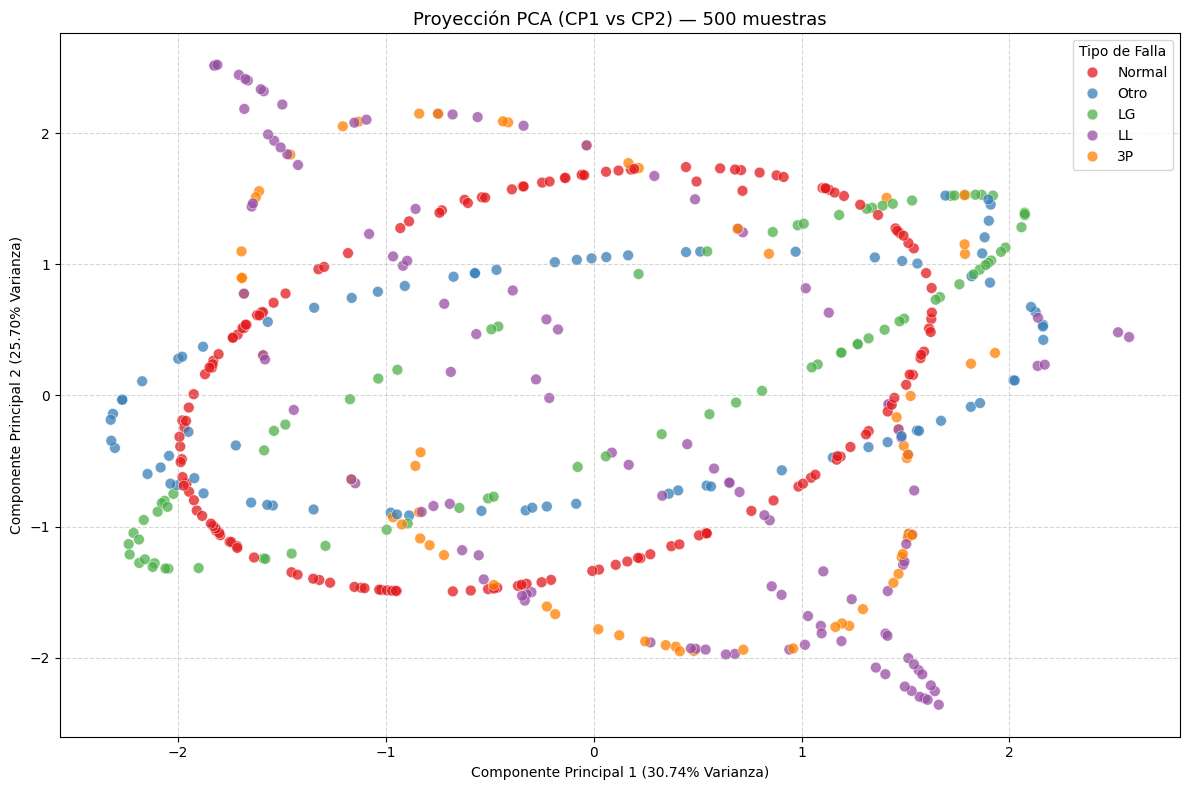

In [ ]:
# =====================================================================
# 6. Realizar gráficos tipo scatterplot coloreados por 'fault_type'
# =====================================================================

# Seleccionamos 500 muestras aleatorias para graficar
df_pca_sampled = df_pca.sample(n=500, random_state=42)

# --- Gráfico CP1 vs CP2 ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='fault_type',
    data=df_pca_sampled,
    palette='Set1',
    alpha=0.75,
    s=60,
    edgecolor='w',
    linewidth=0.4
)
plt.title('Proyección PCA (CP1 vs CP2) — 500 muestras', fontsize=13)
plt.xlabel(f'Componente Principal 1 ({var_explicada[0]:.2f}% Varianza)')
plt.ylabel(f'Componente Principal 2 ({var_explicada[1]:.2f}% Varianza)')
plt.legend(title='Tipo de Falla', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



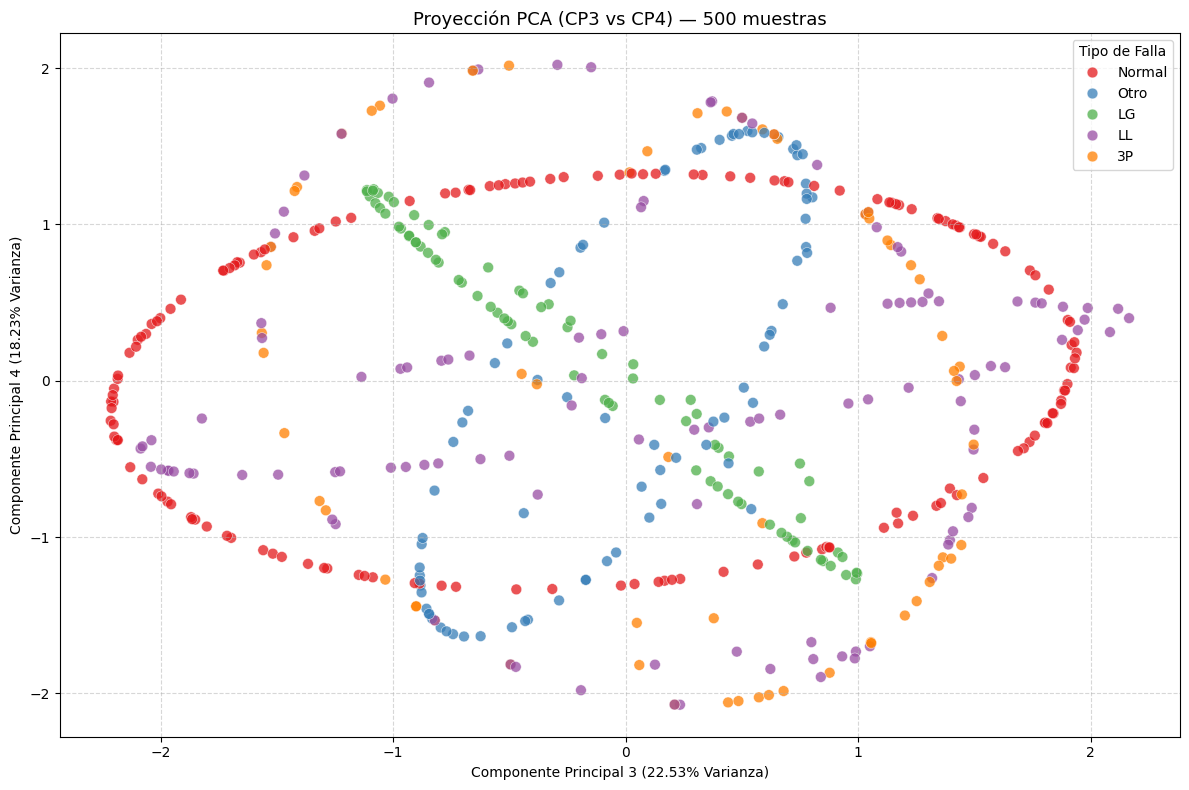

In [ ]:

# --- Gráfico CP3 vs CP4 ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Componente Principal 3',
    y='Componente Principal 4',
    hue='fault_type',
    data=df_pca_sampled,
    palette='Set1',
    alpha=0.75,
    s=60,
    edgecolor='w',
    linewidth=0.4
)
plt.title('Proyección PCA (CP3 vs CP4) — 500 muestras', fontsize=13)
plt.xlabel(f'Componente Principal 3 ({var_explicada[2]:.2f}% Varianza)')
plt.ylabel(f'Componente Principal 4 ({var_explicada[3]:.2f}% Varianza)')
plt.legend(title='Tipo de Falla', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7. Visualización 3D Interactiva (3 Componentes Principales)

In [ ]:
# =====================================================================
# 7. Visualización 3D con las 4 clases de falla
# =====================================================================

# Realizar PCA con 3 componentes
pca_3 = PCA(n_components=3)
X_pca_3d = pca_3.fit_transform(X_scaled)

# Crear un DataFrame para el gráfico 3D
df_pca_3d = pd.DataFrame(
    data=X_pca_3d,
    columns=['Componente Principal 1', 'Componente Principal 2', 'Componente Principal 3']
)
df_pca_3d['fault_type'] = y.values

# Seleccionar 500 muestras aleatorias para graficar
df_pca_3d_sampled = df_pca_3d.sample(n=500, random_state=42)

# Varianza del PCA de 3 componentes
var_3d = pca_3.explained_variance_ratio_ * 100

# Crear el scatterplot 3D interactivo con Plotly
fig = px.scatter_3d(
    df_pca_3d_sampled,
    x='Componente Principal 1',
    y='Componente Principal 2',
    z='Componente Principal 3',
    color='fault_type',
    title='Proyección PCA (3 Componentes) Interactiva — Tipos de Falla PMU (500 muestras)',
    labels={
        'Componente Principal 1': f'CP1 ({var_3d[0]:.2f}%)',
        'Componente Principal 2': f'CP2 ({var_3d[1]:.2f}%)',
        'Componente Principal 3': f'CP3 ({var_3d[2]:.2f}%)'
    },
    color_discrete_sequence=px.colors.qualitative.Set1,
    opacity=0.75
)

fig.update_layout(
    scene=dict(aspectmode='cube'),
    legend_title_text='Tipo de Falla'
)
fig.show()

print(f"Varianza explicada por CP3: {var_3d[2]:.2f}%")
print(f"Varianza total (CP1+CP2+CP3): {sum(var_3d):.2f}%")

Varianza explicada por CP3: 22.53%
Varianza total (CP1+CP2+CP3): 78.97%


---
## 8. Biplot: Variables Originales en el Espacio PCA

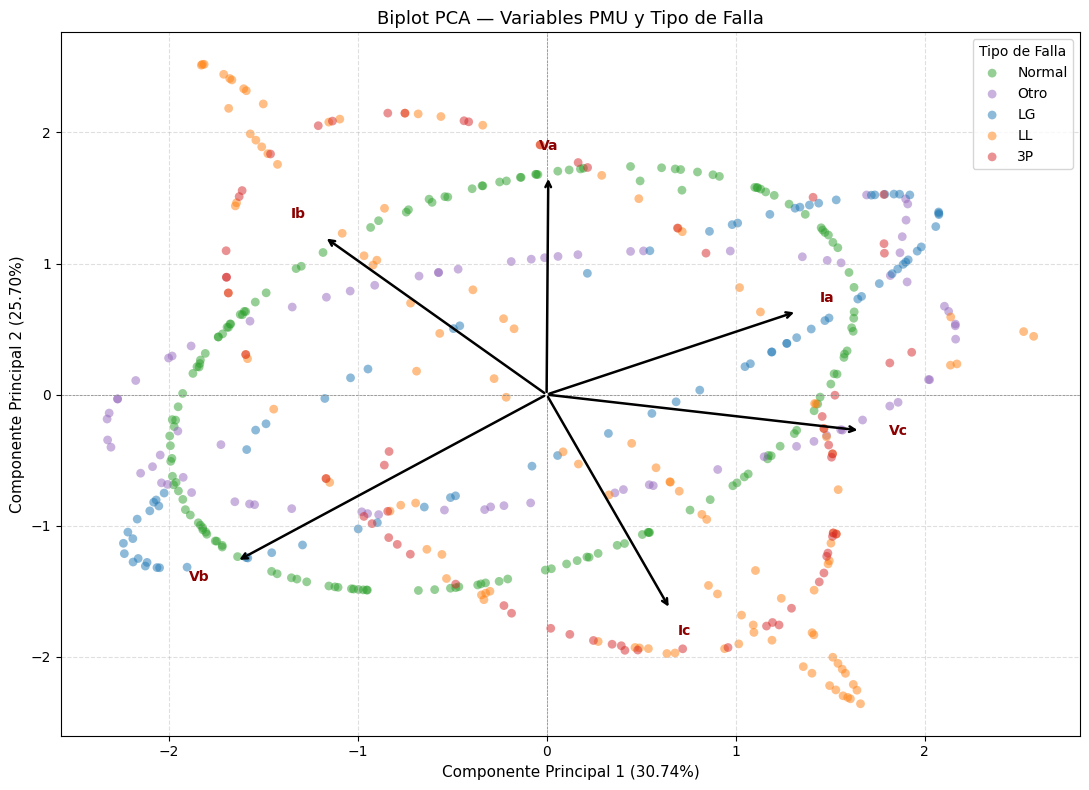

In [ ]:
# =====================================================================
# 8. Biplot: visualizar los loadings sobre el scatterplot PCA
# =====================================================================

loadings = pca_2.components_.T  # shape: (n_features, 2)
escala = 3  # factor de escala para las flechas

fig, ax = plt.subplots(figsize=(11, 8))

# Scatterplot coloreado por tipo de falla
colores_clase = {'Normal': '#2ca02c', 'LG': '#1f77b4', 'LL': '#ff7f0e', '3P': '#d62728', 'Otro': '#9467bd'}
for clase in df_pca_sampled['fault_type'].unique():
    color = colores_clase.get(clase, '#7f7f7f')
    mask = df_pca_sampled['fault_type'] == clase
    ax.scatter(
        df_pca_sampled.loc[mask, 'Componente Principal 1'],
        df_pca_sampled.loc[mask, 'Componente Principal 2'],
        c=color, label=clase, alpha=0.5, s=40, edgecolors='none'
    )

# Flechas de los loadings
for i, feature in enumerate(features):
    ax.annotate(
        '',
        xy=(loadings[i, 0] * escala, loadings[i, 1] * escala),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.8)
    )
    ax.text(
        loadings[i, 0] * escala * 1.12,
        loadings[i, 1] * escala * 1.12,
        feature,
        fontsize=10,
        ha='center',
        color='darkred',
        fontweight='bold'
    )

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'Componente Principal 1 ({var_explicada[0]:.2f}%)', fontsize=11)
ax.set_ylabel(f'Componente Principal 2 ({var_explicada[1]:.2f}%)', fontsize=11)
ax.set_title('Biplot PCA — Variables PMU y Tipo de Falla', fontsize=13)
ax.legend(title='Tipo de Falla', loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# 9. Análisis de Resultados

---
## 9.1 Matriz de Covarianza

### Relaciones entre corrientes (Ia, Ib, Ic)
- **Ia vs Ib (-0.37)** y **Ib vs Ic (-0.53)** muestran correlaciones negativas moderadas, lo que indica que cuando una corriente aumenta, la otra tiende a disminuir.  
- **Ia vs Ic (-0.28)** también es negativa, aunque más débil.  
Esto sugiere que las tres corrientes no están perfectamente balanceadas y existe cierta oposición entre ellas.

### Relaciones entre voltajes (Va, Vb, Vc)
- **Va vs Vb (-0.48)** y **Va vs Vc (-0.45)** presentan correlaciones negativas fuertes.  
- **Vb vs Vc (-0.57)** es la más marcada, mostrando que los voltajes de fases B y C tienden a variar en direcciones opuestas.  
Esto refleja un desbalance o desfase significativo entre las fases de voltaje.

### Relaciones entre corrientes y voltajes
- En general, las correlaciones entre corrientes y voltajes son **bajas** (cercanas a cero), como **Ia vs Va (0.04)** o **Ib vs Va (0.03)**.  
- Algunas son ligeramente negativas (**Ic vs Va -0.07**, **Ib vs Vc -0.06**) y otras positivas (**Ia vs Vc 0.25**).  
Esto indica que no existe una relación lineal fuerte entre las magnitudes de corriente y voltaje en este conjunto de datos.

Conclusión general

- Las corrientes muestran correlaciones negativas moderadas entre sí, lo que sugiere desequilibrio en el sistema trifásico.Este desbalance puede generar pérdidas adicionales, calentamiento en conductores y hasta problemas en equipos sensibles.  
- Los voltajes presentan correlaciones negativas fuertes, especialmente entre Vb y Vc, lo que apunta a un desfase o desbalance más pronunciado en las tensiones.En la práctica, un voltaje desequilibrado puede provocar vibraciones mecánicas en motores y reducir su vida útil.  
- La interacción corriente–voltaje es débil, lo que puede significar que las variaciones de corriente no están directamente ligadas a las variaciones de voltaje en este escenario.Esto puede indicar que hay cargas desequilibradas conectadas al sistema, o que el problema está más en la distribución de tensiones que en la respuesta de las corrientes.

---

## 9.2 Scree Plot y Varianza Explicada

El scree plot revela que los cuatro primeros componentes principales capturan la mayor parte de la varianza del dataset. Esto era esperable dado que las 6 variables originales no son independientes: corrientes y voltajes de las mismas fases covarían fuertemente en condiciones de falla. CP1 (30.74%) + CP2 (25.70%) + CP3 (22.53%) + CP4 (18.23%) = 97.21%  Este resultado confirma que la dimensionalidad del problema puede reducirse de 6 a 4 dimensiones sin pérdida significativa de información.

---

## 9.3 Cargas (Loadings) de los Componentes

* Componente Principal 1 (CP1 – 30.74% varianza)

En este componente, los voltajes **Vc (+0.5532)** y **Vb (-0.5462)** son los que más pesan, mostrando un contraste fuerte entre estas dos fases. Además, las corrientes **Ia (+0.4413)** e **Ib (-0.3917)** también tienen influencia significativa. Esto me dice que CP1 está capturando principalmente el **desequilibrio entre voltajes de fases B y C**, acompañado de un patrón de oposición entre corrientes Ia e Ib. En términos prácticos, este componente refleja cómo ciertas fases de voltaje y corriente se comportan de manera opuesta, lo cual es un indicador de desbalance trifásico.

* Componente Principal 2 (CP2 – 25.70% varianza)

Aquí destacan el voltaje **Va (+0.5526)** y la corriente **Ic (-0.5457)**, junto con aportes de **Ib (+0.4009)** y **Vb (-0.4295)**. Esto significa que CP2 está mostrando una relación fuerte entre la tensión de la fase A y la corriente de la fase C, pero en direcciones contrarias. En la práctica, este componente refleja un **patrón de interacción entre fases específicas**, donde una fase de voltaje y una de corriente se comportan de manera opuesta, lo que puede ser síntoma de cargas desbalanceadas conectadas al sistema.

* Componente Principal 3 (CP3 – 22.53% varianza)

En este caso, los voltajes **Vb (+0.4857)** y **Vc (-0.4857)** son los protagonistas, acompañados por las corrientes **Ib (-0.4217)** e **Ic (+0.3435)**. El patrón es claro: CP3 representa un **contraste fuerte entre las fases B y C**, tanto en voltajes como en corrientes. Esto me indica que este componente está capturando la **oposición entre dos fases del sistema**, lo cual es muy útil para detectar desequilibrios específicos entre pares de fases.

* Componente Principal 4 (CP4 – 18.23% varianza)

Este componente está dominado por la corriente **Ia (+0.6839)**, mientras que **Ib (-0.3938)** e **Ic (-0.3615)** aparecen en oposición. Los voltajes también tienen participación, pero menor. Esto me dice que CP4 refleja principalmente un **desequilibrio en las corrientes**, donde Ia se comporta de manera diferente frente a Ib e Ic. En términos prácticos, este componente es un buen indicador de cómo las corrientes no están balanceadas en el sistema trifásico.

Conclusión general

Cada componente principal está capturando un **patrón distinto de desequilibrio**:  
- CP1 y CP3 se enfocan más en los **voltajes**, especialmente en la oposición entre fases B y C.  
- CP2 y CP4 se enfocan más en las **corrientes**, mostrando cómo ciertas fases se comportan en oposición.  

Como Analista de datos, esto me ayuda a entender que el PCA no solo reduce la dimensionalidad, sino que también me da “lentes” para ver los diferentes tipos de desbalance en el sistema eléctrico.

---

### 9.4 Scatterplot 2D — Separación de Clases

Como estudiante, lo que se puede analizar de esas dos gráficas (CP1 vs CP2 y CP3 vs CP4) es lo siguiente:

* Gráfico CP1 vs CP2

En este espacio bidimensional, que explica más del **56% de la varianza**, se observa cómo los diferentes tipos de falla tienden a formar **agrupaciones**. Por ejemplo, las muestras etiquetadas como “Normal” se concentran en una región, mientras que las fallas como “LG” o “LL” aparecen en zonas distintas. Esto significa que los dos primeros componentes principales son capaces de **separar parcialmente las clases**, mostrando patrones claros de diferenciación. En la práctica, esto indica que el PCA está capturando los desequilibrios más importantes del sistema eléctrico y que ya con CP1 y CP2 se puede empezar a distinguir entre condiciones normales y fallas.

* Gráfico CP3 vs CP4

Este espacio explica otro **40% de la varianza** y complementa la visión anterior. Aquí también se ven **agrupaciones y separaciones** entre tipos de falla, aunque los patrones son diferentes. Por ejemplo, algunas categorías que en CP1–CP2 estaban más mezcladas, en CP3–CP4 aparecen más diferenciadas. Esto quiere decir que los componentes 3 y 4 capturan **otros aspectos del desbalance**, como oposiciones específicas entre fases de voltaje y corrientes. En términos prácticos, este gráfico ayuda a identificar fallas que no se distinguen tan bien en los primeros dos componentes.

Conclusión general

- **CP1–CP2** muestran la separación más fuerte y explican la mayor parte de la variabilidad.  
- **CP3–CP4** aportan información adicional que ayuda a diferenciar mejor ciertos tipos de falla.  
- Juntos, los cuatro componentes permiten construir un espacio donde los **tipos de falla se pueden clasificar con mayor precisión**, lo cual es muy útil para diagnóstico automático y análisis de calidad de energía.  

---

### 9.5 Visualización 3D y Biplot

El análisis de la proyección PCA en 3D (CP1, CP2 y CP3) permite ver de manera más completa cómo se distribuyen los diferentes tipos de falla en el espacio reducido:

Distribución de las fallas
- Los puntos de cada categoría (Normal, LG, LL, 3P, Otro) forman agrupaciones en distintas zonas del espacio tridimensional, esto significa que los tres primeros componentes principales capturan patrones suficientes para separar las condiciones normales de las fallas.  
- Por ejemplo, las muestras “Normal” tienden a concentrarse en una región, mientras que las fallas como “3P” o “LL” aparecen en otras zonas bien diferenciadas.

Aporte de cada componente
- **CP1 (30.74%)**: refleja principalmente el contraste entre voltajes Vb y Vc, y ayuda a separar ciertos tipos de fallas.  
- **CP2 (25.70%)**: está influenciado por Va y algunas corrientes, mostrando otro patrón de diferenciación.  
- **CP3 (22.53%)**: complementa la separación, capturando oposiciones adicionales entre fases de voltaje y corrientes.  
Juntos, estos tres componentes explican casi el **79% de la varianza**, lo que significa que la representación es bastante fiel a los datos originales.

Conclusión general

El gráfico 3D me enseña que:
- Los tres primeros componentes principales son suficientes para **visualizar y diferenciar los tipos de falla** en el sistema eléctrico.  
- Cada tipo de falla ocupa una región distinta en el espacio PCA, lo que facilita la **clasificación automática** y el **diagnóstico de fallas**.  
- En comparación con los gráficos 2D (CP1–CP2 y CP3–CP4), este gráfico 3D ofrece una visión más rica porque combina la información de tres componentes a la vez, mostrando mejor la **separación entre clases**.

---

### 9.6 Conclusión General

Aplicar PCA a mediciones de PMU tiene una relevancia técnica directa en sistemas de potencia. En lugar de analizar 6 señales por separado, el PCA permite reducirlas a 4 o 3 componentes que conservan la información esencial del estado de la línea. Esto es útil para:

1. **Detección rápida de fallas**: una desviación en el espacio PCA puede disparar una alarma en tiempo real.
2. **Visualización del estado de la red**: los operadores pueden monitorear el sistema en un plano 2D interpretable.
3. **Preprocesamiento para clasificadores**: reducir la dimensionalidad mejora la velocidad y precisión de modelos de Machine Learning.

Como reflexión personal, este ejercicio me permitió conectar los conceptos matemáticos del PCA con aplicaciones reales de ingeniería eléctrica en sistemas de protección y microrredes inteligentes, que es el área central de mi investigación en la MAIE.